# Evaluación del LLM y Comparación de Modelos Telco Customer Churn
**Proyecto:** Predicción de Abandono de Clientes con ML + LLM  

## Configuración

In [1]:
import os
import sys
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from dotenv import load_dotenv

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, roc_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
load_dotenv()

# Agregar la raíz del proyecto al path para importar src/
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src.llm import generar_explicacion_churn

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
})

FIG_DIR = '../data/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

print('Configuración lista.')

Configuración lista.


## Carga de datos y split

In [2]:
df = pd.read_csv('../data/telco_clean.csv')
df = df.drop(columns=['customerID'], errors='ignore')
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# El mismo split que en 02_modeling.ipynb para comparar resultados consistentes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'scale_pos_weight para XGBoost: {scale:.2f}')

Train: 5634 | Test: 1409
scale_pos_weight para XGBoost: 2.77


## Comparación de tres modelos: Logistic Regression vs Random Forest vs XGBoost

In [3]:
# Definición de los tres modelos a comparar
# class_weight='balanced' corrige el desbalance en Logistic Regression y Random Forest
# scale_pos_weight hace lo mismo para XGBoost
modelos = {
    'Regresión Logística (Baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=SEED
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
}

resultados = []
probabilidades = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    probabilidades[nombre] = y_prob

    resultados.append({
        'Modelo':     nombre,
        'AUC-ROC':    round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score':   round(f1_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
    })
    print(f'{nombre}: AUC={resultados[-1]["AUC-ROC"]} | F1={resultados[-1]["F1 Score"]}')

tabla = pd.DataFrame(resultados).set_index('Modelo')
print('\nTabla comparativa completa:')
print(tabla.to_string())

Regresión Logística (Baseline): AUC=0.8414 | F1=0.6164
Random Forest: AUC=0.8433 | F1=0.625
XGBoost: AUC=0.8393 | F1=0.6285

Tabla comparativa completa:
                                AUC-ROC  F1 Score  Precision  Recall  Accuracy
Modelo                                                                        
Regresión Logística (Baseline)   0.8414    0.6164     0.5069  0.7861    0.7402
Random Forest                    0.8433    0.6250     0.5119  0.8021    0.7445
XGBoost                          0.8393    0.6285     0.5211  0.7914    0.7516


## Figura 8: Curvas ROC (tres modelos)

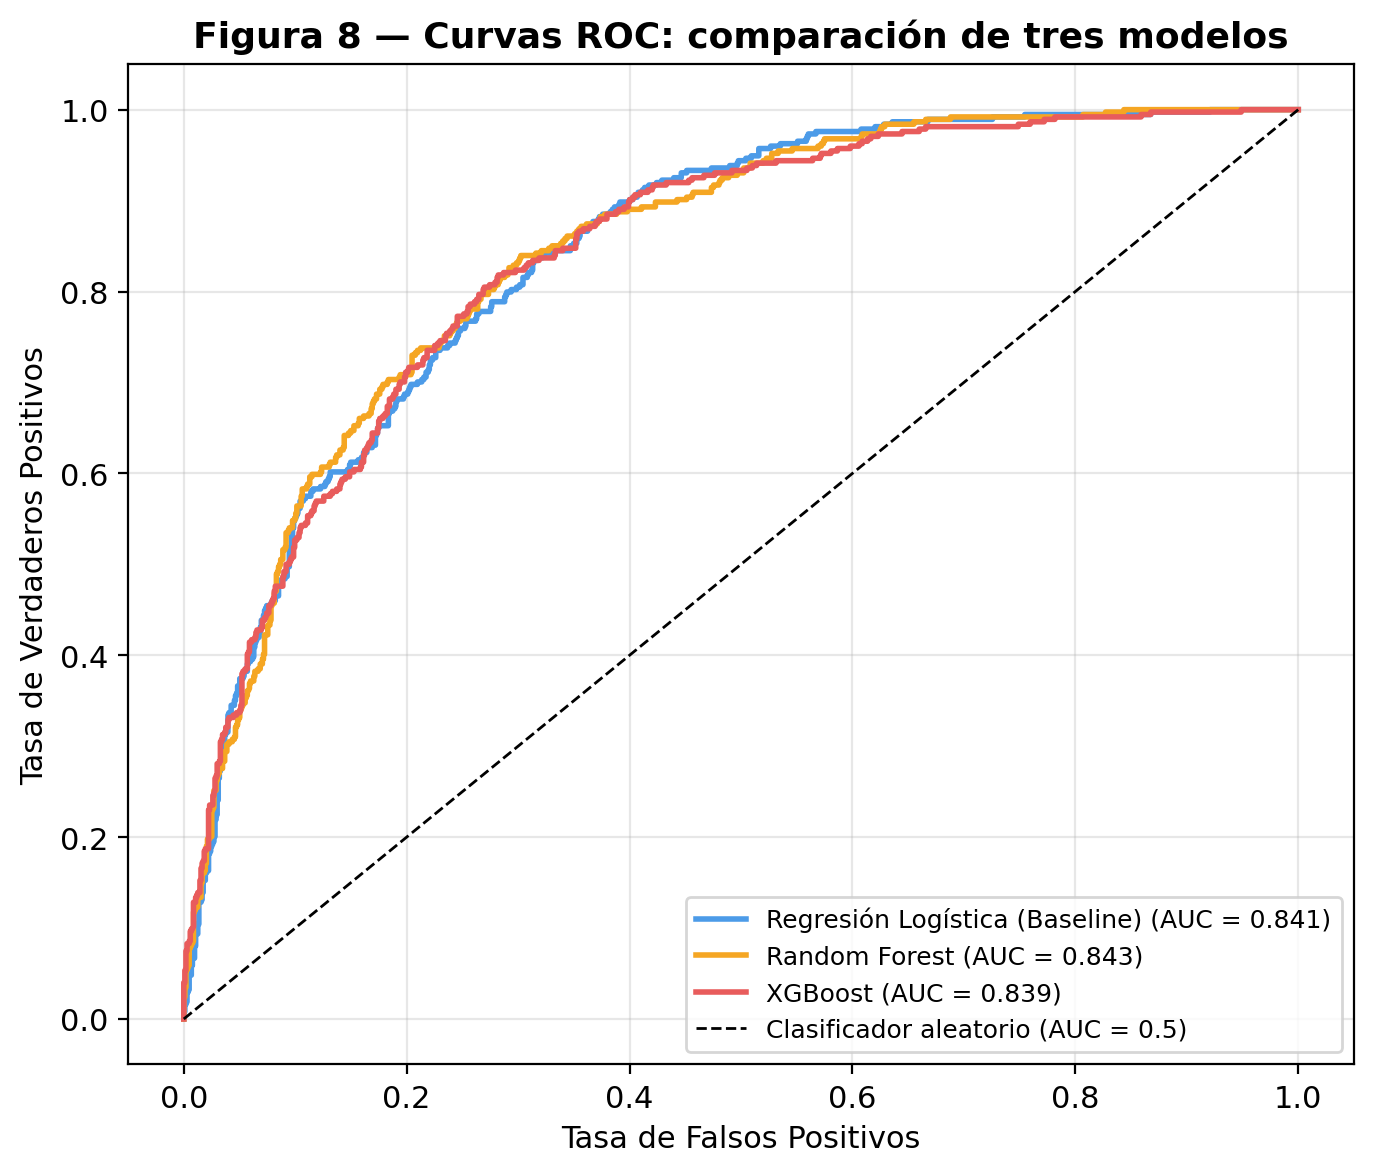

In [4]:
colores = {
    'Regresión Logística (Baseline)': '#4C9BE8',
    'Random Forest':                  '#F5A623',
    'XGBoost':                        '#E85C5C'
}

fig, ax = plt.subplots(figsize=(7, 6))

for nombre, y_prob in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colores[nombre], linewidth=2,
            label=f'{nombre} (AUC = {auc:.3f})')

# Línea de referencia: clasificador aleatorio
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.5)')

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Figura 8 — Curvas ROC: comparación de tres modelos', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig8_roc_three_models.png')
plt.show()

## Evaluación cuantitativa del LLM (15 casos de prueba)

In [5]:
# Cada caso tiene los datos del cliente, la probabilidad de churn predicha
# y las palabras clave que DEBEN aparecer en una buena explicación.
# Esto permite medir objetivamente si el LLM menciona los factores correctos.
casos_de_prueba = [
    {
        'id': 1,
        'descripcion': 'Cliente nuevo con contrato mes a mes y fibra óptica',
        'datos': {
            'tenure': 2, 'Contract': 'Month-to-month',
            'MonthlyCharges': 85.5, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.82,
        'riesgo_esperado': 'alto',
        'keywords_esperadas': ['contrato', 'mes', 'meses']
    },
    {
        'id': 2,
        'descripcion': 'Cliente fiel con contrato bianual y DSL',
        'datos': {
            'tenure': 60, 'Contract': 'Two year',
            'MonthlyCharges': 45.0, 'InternetService': 'DSL',
            'TechSupport': 'Yes', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Bank transfer (automatic)', 'Partner': 'Yes', 'Dependents': 'Yes'
        },
        'probabilidad': 0.08,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'fidelidad', 'contrato', 'años']
    },
    {
        'id': 3,
        'descripcion': 'Cliente con cargo alto, sin soporte técnico',
        'datos': {
            'tenure': 10, 'Contract': 'Month-to-month',
            'MonthlyCharges': 100.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.75,
        'riesgo_esperado': 'alto',
        'keywords_esperadas': ['soporte', 'cargo', 'contrato']
    },
    {
        'id': 4,
        'descripcion': 'Cliente con riesgo medio, contrato anual',
        'datos': {
            'tenure': 18, 'Contract': 'One year',
            'MonthlyCharges': 65.0, 'InternetService': 'DSL',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Mailed check', 'Partner': 'Yes', 'Dependents': 'No'
        },
        'probabilidad': 0.45,
        'riesgo_esperado': 'medio',
        'keywords_esperadas': ['medio', 'moderado', 'riesgo']
    },
    {
        'id': 5,
        'descripcion': 'Senior citizen sin pareja, fibra óptica cara',
        'datos': {
            'tenure': 5, 'Contract': 'Month-to-month',
            'MonthlyCharges': 95.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.78,
        'riesgo_esperado': 'alto',
        'keywords_esperadas': ['contrato', 'cargo', 'meses']
    },
    {
        'id': 6,
        'descripcion': 'Cliente con soporte técnico y contrato anual',
        'datos': {
            'tenure': 30, 'Contract': 'One year',
            'MonthlyCharges': 55.0, 'InternetService': 'DSL',
            'TechSupport': 'Yes', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Credit card (automatic)', 'Partner': 'Yes', 'Dependents': 'No'
        },
        'probabilidad': 0.22,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'soporte', 'contrato']
    },
    {
        'id': 7,
        'descripcion': 'Cliente muy nuevo sin ningún servicio adicional',
        'datos': {
            'tenure': 1, 'Contract': 'Month-to-month',
            'MonthlyCharges': 70.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.88,
        'riesgo_esperado': 'alto',
        'keywords_esperadas': ['nuevo', 'mes', 'contrato']
    },
    {
        'id': 8,
        'descripcion': 'Cliente antiguo con todos los servicios',
        'datos': {
            'tenure': 70, 'Contract': 'Two year',
            'MonthlyCharges': 80.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'Yes', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Credit card (automatic)', 'Partner': 'Yes', 'Dependents': 'Yes'
        },
        'probabilidad': 0.05,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'fidelidad', 'años']
    },
    {
        'id': 9,
        'descripcion': 'Cliente con factura muy alta y pago electrónico',
        'datos': {
            'tenure': 8, 'Contract': 'Month-to-month',
            'MonthlyCharges': 110.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.80,
        'riesgo_esperado': 'alto',
        'keywords_esperadas': ['cargo', 'factura', 'contrato']
    },
    {
        'id': 10,
        'descripcion': 'Cliente con riesgo medio, sin dependientes',
        'datos': {
            'tenure': 20, 'Contract': 'One year',
            'MonthlyCharges': 72.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Mailed check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.48,
        'riesgo_esperado': 'medio',
        'keywords_esperadas': ['riesgo', 'moderado', 'contrato']
    },
    {
        'id': 11,
        'descripcion': 'Cliente con pareja y contrato anual, bajo riesgo',
        'datos': {
            'tenure': 40, 'Contract': 'One year',
            'MonthlyCharges': 50.0, 'InternetService': 'DSL',
            'TechSupport': 'Yes', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Bank transfer (automatic)', 'Partner': 'Yes', 'Dependents': 'Yes'
        },
        'probabilidad': 0.15,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'contrato', 'soporte']
    },
    {
        'id': 12,
        'descripcion': 'Cliente nuevo sin internet',
        'datos': {
            'tenure': 3, 'Contract': 'Month-to-month',
            'MonthlyCharges': 25.0, 'InternetService': 'No',
            'TechSupport': 'No', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Mailed check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.35,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['contrato', 'meses', 'bajo']
    },
    {
        'id': 13,
        'descripcion': 'Cliente con fibra óptica y contrato bianual',
        'datos': {
            'tenure': 50, 'Contract': 'Two year',
            'MonthlyCharges': 90.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'Yes', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Credit card (automatic)', 'Partner': 'Yes', 'Dependents': 'No'
        },
        'probabilidad': 0.12,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'contrato', 'años']
    },
    {
        'id': 14,
        'descripcion': 'Cliente con cargo moderado y riesgo medio',
        'datos': {
            'tenure': 15, 'Contract': 'Month-to-month',
            'MonthlyCharges': 60.0, 'InternetService': 'DSL',
            'TechSupport': 'No', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'Partner': 'No', 'Dependents': 'No'
        },
        'probabilidad': 0.52,
        'riesgo_esperado': 'medio',
        'keywords_esperadas': ['contrato', 'riesgo', 'meses']
    },
    {
        'id': 15,
        'descripcion': 'Cliente con tenure muy alto y todos los servicios',
        'datos': {
            'tenure': 72, 'Contract': 'Two year',
            'MonthlyCharges': 75.0, 'InternetService': 'Fiber optic',
            'TechSupport': 'Yes', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Bank transfer (automatic)', 'Partner': 'Yes', 'Dependents': 'Yes'
        },
        'probabilidad': 0.04,
        'riesgo_esperado': 'bajo',
        'keywords_esperadas': ['bajo', 'fidelidad', 'años']
    }
]

print(f'Set de evaluación: {len(casos_de_prueba)} casos de prueba')
print('Distribución de riesgo esperado:')
riesgos = [c['riesgo_esperado'] for c in casos_de_prueba]
for nivel in ['alto', 'medio', 'bajo']:
    print(f'  {nivel}: {riesgos.count(nivel)} casos')

Set de evaluación: 15 casos de prueba
Distribución de riesgo esperado:
  alto: 5 casos
  medio: 3 casos
  bajo: 7 casos


In [6]:
def evaluar_respuesta(explicacion: str, keywords_esperadas: list, riesgo_esperado: str, probabilidad: float) -> dict:
    """
    Evalúa una explicación del LLM en tres dimensiones:
    1. Keyword match: menciona al menos una palabra clave esperada
    2. Nivel de riesgo correcto: menciona el nivel esperado (alto/medio/bajo)
    3. Longitud adecuada: entre 50 y 400 palabras
    """
    explicacion_lower = explicacion.lower()

    # Criterio 1: menciona al menos una keyword esperada
    keywords_encontradas = [kw for kw in keywords_esperadas if kw.lower() in explicacion_lower]
    keyword_ok = len(keywords_encontradas) >= 1

    # Criterio 2: menciona el nivel de riesgo correcto
    nivel_ok = riesgo_esperado.lower() in explicacion_lower

    # Criterio 3: longitud adecuada (no muy corta ni excesivamente larga)
    n_palabras = len(explicacion.split())
    longitud_ok = 50 <= n_palabras <= 400

    score = sum([keyword_ok, nivel_ok, longitud_ok])

    return {
        'keyword_ok':           keyword_ok,
        'keywords_encontradas': keywords_encontradas,
        'nivel_ok':             nivel_ok,
        'longitud_ok':          longitud_ok,
        'n_palabras':           n_palabras,
        'score':                score,
        'score_pct':            round(score / 3 * 100, 1)
    }


print('Ejecutando evaluación del LLM — esto puede tardar 1-2 minutos...')
print('(Se hacen 15 llamadas a Groq, una por caso de prueba)')
print()

resultados_llm = []

for caso in casos_de_prueba:
    try:
        explicacion = generar_explicacion_churn(caso['datos'], caso['probabilidad'])
        evaluacion  = evaluar_respuesta(
            explicacion,
            caso['keywords_esperadas'],
            caso['riesgo_esperado'],
            caso['probabilidad']
        )
        estado = 'OK'
    except Exception as e:
        explicacion = f'ERROR: {e}'
        evaluacion  = {'keyword_ok': False, 'nivel_ok': False, 'longitud_ok': False,
                       'score': 0, 'score_pct': 0, 'n_palabras': 0, 'keywords_encontradas': []}
        estado = 'ERROR'

    resultados_llm.append({
        'id':           caso['id'],
        'descripcion':  caso['descripcion'],
        'probabilidad': caso['probabilidad'],
        'riesgo_esperado': caso['riesgo_esperado'],
        'explicacion':  explicacion,
        'estado':       estado,
        **evaluacion
    })

    icono = '✅' if evaluacion['score'] == 3 else '⚠️' if evaluacion['score'] >= 2 else '❌'
    print(f"Caso {caso['id']:2d} {icono} | Score: {evaluacion['score']}/3 | {caso['descripcion']}")

print('\nEvaluación completada.')

Ejecutando evaluación del LLM — esto puede tardar 1-2 minutos...
(Se hacen 15 llamadas a Groq, una por caso de prueba)

Caso  1 ✅ | Score: 3/3 | Cliente nuevo con contrato mes a mes y fibra óptica
Caso  2 ✅ | Score: 3/3 | Cliente fiel con contrato bianual y DSL
Caso  3 ✅ | Score: 3/3 | Cliente con cargo alto, sin soporte técnico
Caso  4 ✅ | Score: 3/3 | Cliente con riesgo medio, contrato anual
Caso  5 ✅ | Score: 3/3 | Senior citizen sin pareja, fibra óptica cara
Caso  6 ✅ | Score: 3/3 | Cliente con soporte técnico y contrato anual
Caso  7 ✅ | Score: 3/3 | Cliente muy nuevo sin ningún servicio adicional
Caso  8 ✅ | Score: 3/3 | Cliente antiguo con todos los servicios
Caso  9 ✅ | Score: 3/3 | Cliente con factura muy alta y pago electrónico
Caso 10 ⚠️ | Score: 2/3 | Cliente con riesgo medio, sin dependientes
Caso 11 ✅ | Score: 3/3 | Cliente con pareja y contrato anual, bajo riesgo
Caso 12 ⚠️ | Score: 2/3 | Cliente nuevo sin internet
Caso 13 ✅ | Score: 3/3 | Cliente con fibra óptica y cont

## Resumen de resultados de la evaluación

In [ ]:
df_eval = pd.DataFrame(resultados_llm)

total     = len(df_eval)
perfectos = (df_eval['score'] == 3).sum()
buenos    = (df_eval['score'] == 2).sum()
malos     = (df_eval['score'] <= 1).sum()
score_promedio = df_eval['score_pct'].mean()

keyword_rate = df_eval['keyword_ok'].mean() * 100
nivel_rate   = df_eval['nivel_ok'].mean() * 100
longitud_rate = df_eval['longitud_ok'].mean() * 100

print('Resumen de evaluación del LLM:')
print(f'Total de casos evaluados : {total}')
print(f'Score promedio           : {score_promedio:.1f}%')
print()
print(f'Casos perfectos (3/3)    : {perfectos} ({perfectos/total*100:.0f}%)')
print(f'Casos buenos    (2/3)    : {buenos}  ({buenos/total*100:.0f}%)')
print(f'Casos malos     (≤1/3)   : {malos}   ({malos/total*100:.0f}%)')
print()
print(f'Keyword correcta         : {keyword_rate:.0f}%')
print(f'Nivel de riesgo correcto : {nivel_rate:.0f}%')
print(f'Longitud adecuada        : {longitud_rate:.0f}%')

# Guardar resultados completos para el informe
df_eval[['id','descripcion','probabilidad','riesgo_esperado',
         'score','score_pct','keyword_ok','nivel_ok','longitud_ok']].to_csv(
    '../data/llm_evaluation_results.csv', index=False
)
print('\nResultados guardados en data/llm_evaluation_results.csv')

RESUMEN DE EVALUACIÓN DEL LLM
Total de casos evaluados : 15
Score promedio           : 93.3%

Casos perfectos (3/3)    : 12 (80%)
Casos buenos    (2/3)    : 3  (20%)
Casos malos     (≤1/3)   : 0   (0%)

Keyword correcta         : 100%
Nivel de riesgo correcto : 80%
Longitud adecuada        : 100%

Resultados guardados en data/llm_evaluation_results.csv


## Figura 9: Resultados de la evaluación del LLM

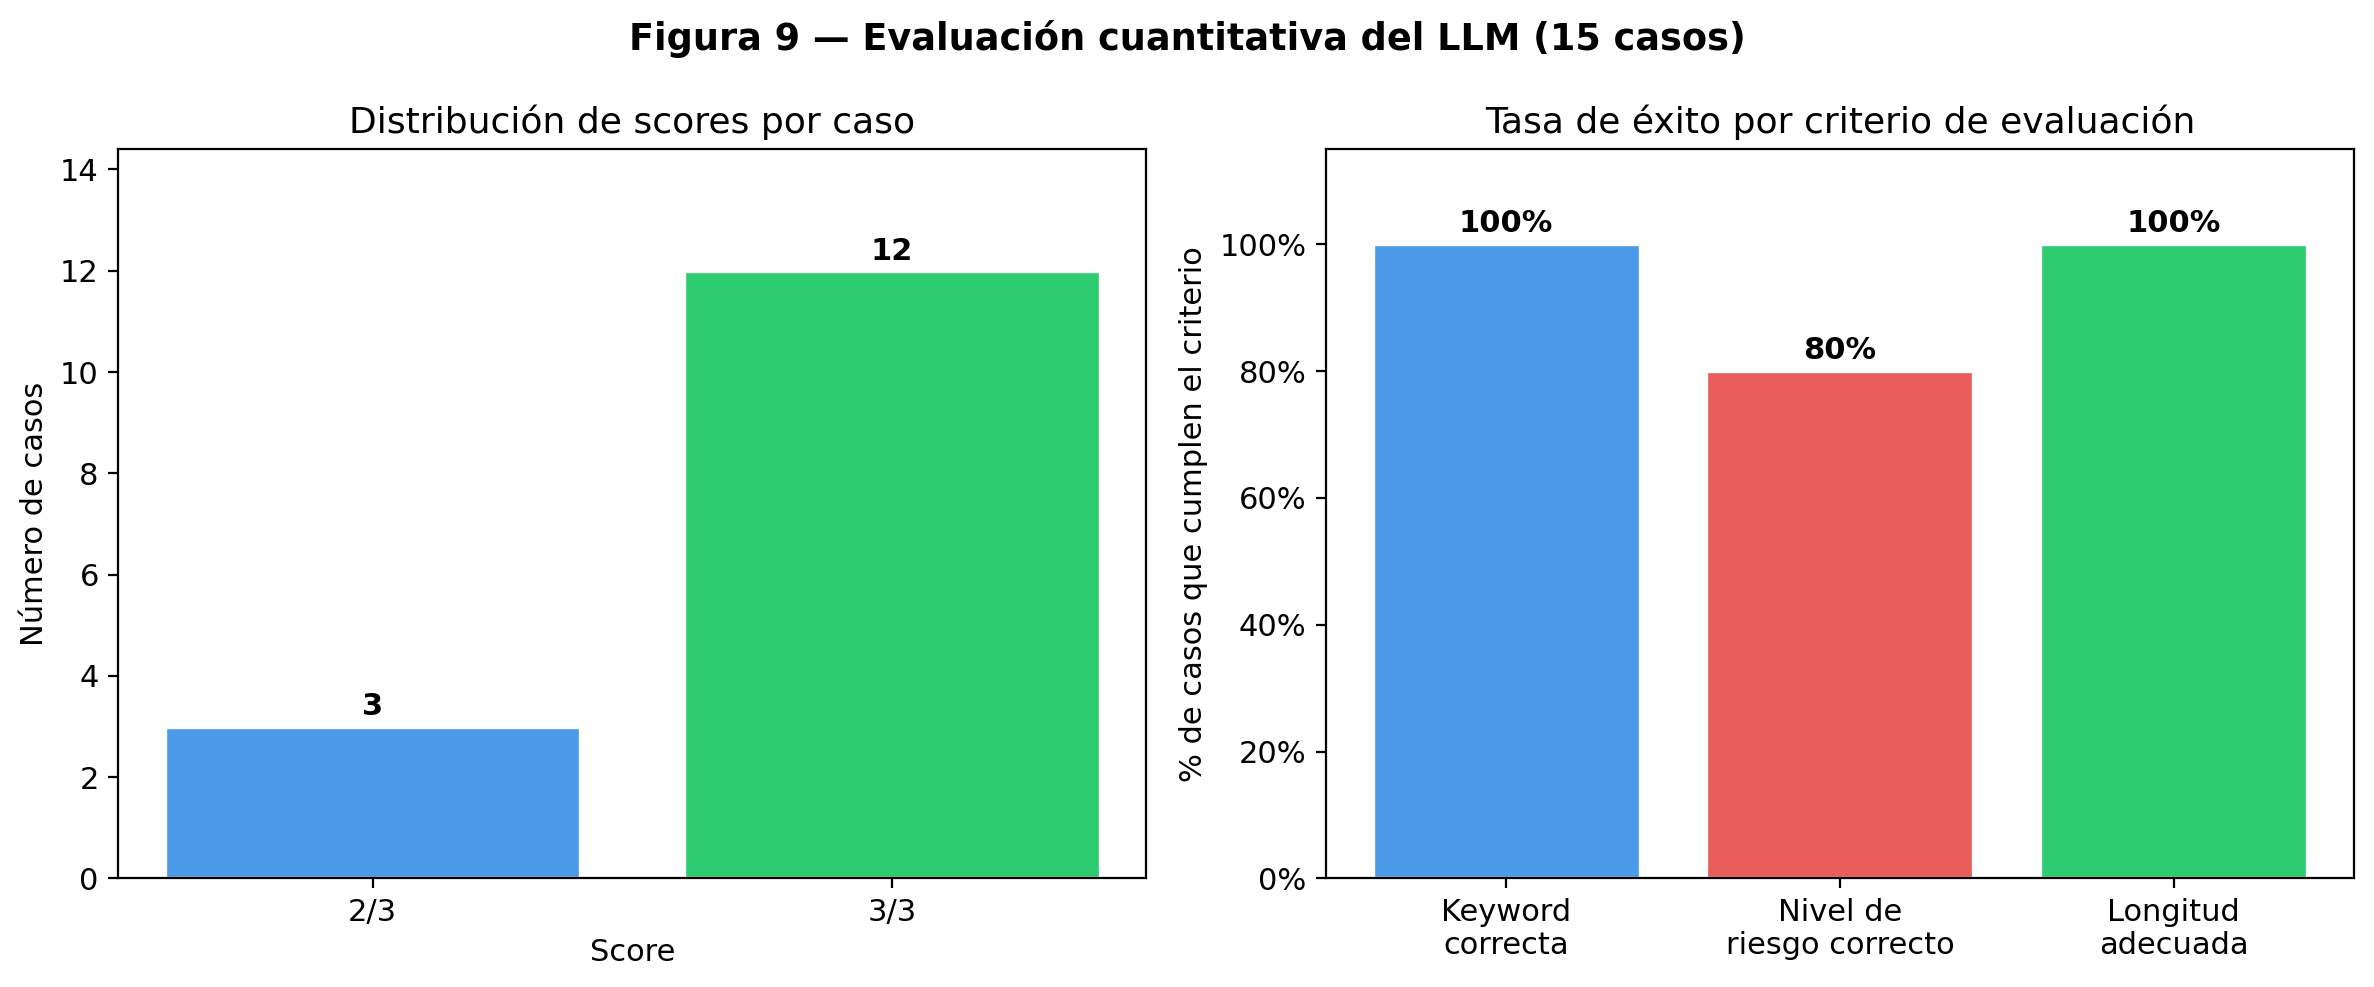

Score promedio del LLM: 93.3%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1: distribución de scores
score_counts = df_eval['score'].value_counts().sort_index()
colores_score = {0: '#E85C5C', 1: '#F5A623', 2: '#4C9BE8', 3: '#2ECC71'}
bars = axes[0].bar(
    [f'{s}/3' for s in score_counts.index],
    score_counts.values,
    color=[colores_score[s] for s in score_counts.index],
    edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1, str(val),
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de scores por caso')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Número de casos')
axes[0].set_ylim(0, score_counts.max() * 1.2)

# Gráfica 2: tasa de éxito por criterio
criterios = ['Keyword\ncorrecta', 'Nivel de\nriesgo correcto', 'Longitud\nadecuada']
tasas = [keyword_rate, nivel_rate, longitud_rate]
bars2 = axes[1].bar(criterios, tasas,
                    color=['#4C9BE8', '#E85C5C', '#2ECC71'],
                    edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{val:.0f}%',
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Tasa de éxito por criterio de evaluación')
axes[1].set_ylabel('% de casos que cumplen el criterio')
axes[1].set_ylim(0, 115)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Figura 9 — Evaluación cuantitativa del LLM (15 casos)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig9_llm_evaluation.png')
plt.show()

print(f'Score promedio del LLM: {score_promedio:.1f}%')

## Ejemplos de explicaciones generadas

In [9]:
# Mostrar un ejemplo de cada nivel de riesgo para el informe
for nivel in ['alto', 'medio', 'bajo']:
    caso = next((r for r in resultados_llm if r['riesgo_esperado'] == nivel), None)
    if caso:
        print(f'RIESGO {nivel.upper()} — Caso {caso["id"]}: {caso["descripcion"]}')
        print(f'Probabilidad: {caso["probabilidad"]:.0%}')
        print(f'Score: {caso["score"]}/3')
        print(f'Explicación:')
        print(caso['explicacion'])
        print('-' * 60)
        print()

RIESGO ALTO — Caso 1: Cliente nuevo con contrato mes a mes y fibra óptica
Probabilidad: 82%
Score: 3/3
Explicación:
El cliente en cuestión tiene un alto riesgo de abandono (churn) debido a varias características que lo hacen vulnerable a dejar la empresa de telecomunicaciones. El principal motivo es que tiene un contrato month-to-month, lo que significa que no tiene obligación contractual de permanecer con la empresa, lo que lo hace más propenso a cambiar de proveedor. Otro factor determinante es que es un cliente nuevo, ya que tiene solo 2 meses de contrato, lo que reduce su compromiso con la empresa. Además, no cuenta con soporte técnico, lo que podría generar frustración y pérdida de confianza en la empresa. En resumen, recomiendo ofrecerle al cliente un plan de fidelización personalizado que incluya una promoción de precio, un aumento en el soporte técnico y un incentivo para comprometerse a un contrato de mayor duración.
------------------------------------------------------------